In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("kc_house_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [4]:
df.drop(columns=['id','date'], inplace=True)

In [5]:
X = df.drop("price", axis=1)
y = df["price"]

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

linear_pred = lr.predict(X_test)

In [8]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, linear_pred))
print("MSE :", mean_squared_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R2 Score:", r2_score(y_test, linear_pred))

Linear Regression
MAE : 127491.83403586817
MSE : 45172118064.677025
RMSE: 212537.3333432906
R2 Score: 0.7011965838499821


In [9]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

In [10]:
print("Polynomial Regression")

print("MAE :", mean_absolute_error(y_test, poly_pred))
print("MSE :", mean_squared_error(y_test, poly_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
print("R2 Score:", r2_score(y_test, poly_pred))

Polynomial Regression
MAE : 108778.09265895798
MSE : 34315609171.771786
RMSE: 185244.7277840095
R2 Score: 0.7730099519993007


In [11]:
# ============================================
# Feature Selection Experiment
# ============================================
# Let's check which features are most correlated with price
corr_with_price = df.corr(numeric_only=True)["price"].drop("price").sort_values(ascending=False)
print("Correlation of features with Price:\n")
print(corr_with_price)

Correlation of features with Price:

sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


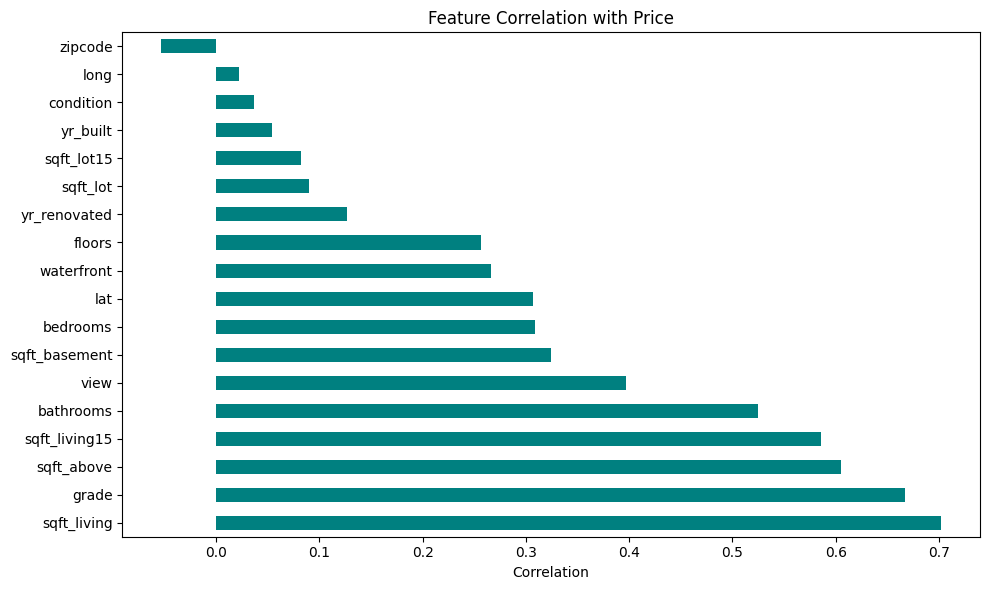

In [12]:
# Visualize feature correlations with price
plt.figure(figsize=(10, 6))
corr_with_price.plot(kind='barh', color='teal')
plt.title("Feature Correlation with Price")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

In [13]:
# ============================================
# Experiment 1: Keep ONLY top correlated features
# ============================================
top_features = ["sqft_living", "grade", "sqft_above", "sqft_living15", "bathrooms"]
print("Selected features:", top_features)

X_top = df[top_features]
y_top = df["price"]

X_top_train, X_top_test, y_top_train, y_top_test = train_test_split(
    X_top, y_top, test_size=0.2, random_state=42
)

# Impute NaNs
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
X_top_train = pd.DataFrame(imp.fit_transform(X_top_train), columns=top_features, index=X_top_train.index)
X_top_test = pd.DataFrame(imp.transform(X_top_test), columns=top_features, index=X_top_test.index)

# Linear Regression
lr_top = LinearRegression()
lr_top.fit(X_top_train, y_top_train)
lr_top_pred = lr_top.predict(X_top_test)

print("\n--- Linear Regression (Top 5 Features) ---")
print("MAE :", mean_absolute_error(y_top_test, lr_top_pred))
print("MSE :", mean_squared_error(y_top_test, lr_top_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_top_test, lr_top_pred)))
print("R2  :", r2_score(y_top_test, lr_top_pred))

# Polynomial Regression
poly_top = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
poly_top.fit(X_top_train, y_top_train)
poly_top_pred = poly_top.predict(X_top_test)

print("\n--- Polynomial Regression (Top 5 Features) ---")
print("MAE :", mean_absolute_error(y_top_test, poly_top_pred))
print("MSE :", mean_squared_error(y_top_test, poly_top_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_top_test, poly_top_pred)))
print("R2  :", r2_score(y_top_test, poly_top_pred))

Selected features: ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms']

--- Linear Regression (Top 5 Features) ---
MAE : 164501.74265543107
MSE : 68325711954.40768
RMSE: 261391.874308303
R2  : 0.5480407601514778

--- Polynomial Regression (Top 5 Features) ---
MAE : 153448.0520394423
MSE : 66285371123.56185
RMSE: 257459.45530036735
R2  : 0.5615371565235538


In [14]:
# ============================================
# Experiment 2: Keep ONLY 2 features (sqft_living + grade)
# ============================================
minimal_features = ["sqft_living", "grade"]
print("Selected features:", minimal_features)

X_min = df[minimal_features]
y_min = df["price"]

X_min_train, X_min_test, y_min_train, y_min_test = train_test_split(
    X_min, y_min, test_size=0.2, random_state=42
)

# Linear Regression
lr_min = LinearRegression()
lr_min.fit(X_min_train, y_min_train)
lr_min_pred = lr_min.predict(X_min_test)

print("\n--- Linear Regression (2 Features) ---")
print("MAE :", mean_absolute_error(y_min_test, lr_min_pred))
print("MSE :", mean_squared_error(y_min_test, lr_min_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_min_test, lr_min_pred)))
print("R2  :", r2_score(y_min_test, lr_min_pred))

# Polynomial Regression
poly_min = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
poly_min.fit(X_min_train, y_min_train)
poly_min_pred = poly_min.predict(X_min_test)

print("\n--- Polynomial Regression (2 Features) ---")
print("MAE :", mean_absolute_error(y_min_test, poly_min_pred))
print("MSE :", mean_squared_error(y_min_test, poly_min_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_min_test, poly_min_pred)))
print("R2  :", r2_score(y_min_test, poly_min_pred))

Selected features: ['sqft_living', 'grade']

--- Linear Regression (2 Features) ---
MAE : 167685.20280375212
MSE : 69834518251.59691
RMSE: 264262.2149524917
R2  : 0.5380603453464137

--- Polynomial Regression (2 Features) ---
MAE : 158526.15806962334
MSE : 68117250197.803085
RMSE: 260992.8163720279
R2  : 0.5494196878546441


In [15]:
# ============================================
# Experiment 3: Drop low-correlation / noisy features
# ============================================
drop_cols = ["zipcode", "yr_renovated", "sqft_lot", "sqft_lot15", "condition"]
keep_cols = [c for c in df.columns if c not in drop_cols and c != "price"]
print("Keeping:", keep_cols)
print("Dropped:", drop_cols)

X_drop = df[keep_cols]
y_drop = df["price"]

X_drop_train, X_drop_test, y_drop_train, y_drop_test = train_test_split(
    X_drop, y_drop, test_size=0.2, random_state=42
)

imp2 = SimpleImputer(strategy='median')
X_drop_train = pd.DataFrame(imp2.fit_transform(X_drop_train), columns=keep_cols, index=X_drop_train.index)
X_drop_test = pd.DataFrame(imp2.transform(X_drop_test), columns=keep_cols, index=X_drop_test.index)

# Linear Regression
lr_drop = LinearRegression()
lr_drop.fit(X_drop_train, y_drop_train)
lr_drop_pred = lr_drop.predict(X_drop_test)

print("\n--- Linear Regression (Dropped Low-Corr) ---")
print("MAE :", mean_absolute_error(y_drop_test, lr_drop_pred))
print("MSE :", mean_squared_error(y_drop_test, lr_drop_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_drop_test, lr_drop_pred)))
print("R2  :", r2_score(y_drop_test, lr_drop_pred))

# Polynomial Regression
poly_drop = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
poly_drop.fit(X_drop_train, y_drop_train)
poly_drop_pred = poly_drop.predict(X_drop_test)

print("\n--- Polynomial Regression (Dropped Low-Corr) ---")
print("MAE :", mean_absolute_error(y_drop_test, poly_drop_pred))
print("MSE :", mean_squared_error(y_drop_test, poly_drop_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_drop_test, poly_drop_pred)))
print("R2  :", r2_score(y_drop_test, poly_drop_pred))

Keeping: ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'lat', 'long', 'sqft_living15']
Dropped: ['zipcode', 'yr_renovated', 'sqft_lot', 'sqft_lot15', 'condition']

--- Linear Regression (Dropped Low-Corr) ---
MAE : 129481.87241203291
MSE : 46601298202.57967
RMSE: 215873.33833194798
R2  : 0.6917428782059911



--- Polynomial Regression (Dropped Low-Corr) ---
MAE : 110127.85179362845
MSE : 34909384688.86453
RMSE: 186840.5327782613
R2  : 0.7690822603050674


In [16]:
# ============================================
# COMPARISON TABLE: All Experiments
# ============================================
results = pd.DataFrame({
    "Model": [
        "Linear (All Features)",
        "Poly (All Features)",
        "Linear (Top 5)",
        "Poly (Top 5)",
        "Linear (2 Features)",
        "Poly (2 Features)",
        "Linear (Drop Low-Corr)",
        "Poly (Drop Low-Corr)"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, poly_pred),
        mean_absolute_error(y_top_test, lr_top_pred),
        mean_absolute_error(y_top_test, poly_top_pred),
        mean_absolute_error(y_min_test, lr_min_pred),
        mean_absolute_error(y_min_test, poly_min_pred),
        mean_absolute_error(y_drop_test, lr_drop_pred),
        mean_absolute_error(y_drop_test, poly_drop_pred),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, poly_pred)),
        np.sqrt(mean_squared_error(y_top_test, lr_top_pred)),
        np.sqrt(mean_squared_error(y_top_test, poly_top_pred)),
        np.sqrt(mean_squared_error(y_min_test, lr_min_pred)),
        np.sqrt(mean_squared_error(y_min_test, poly_min_pred)),
        np.sqrt(mean_squared_error(y_drop_test, lr_drop_pred)),
        np.sqrt(mean_squared_error(y_drop_test, poly_drop_pred)),
    ],
    "R2 Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, poly_pred),
        r2_score(y_top_test, lr_top_pred),
        r2_score(y_top_test, poly_top_pred),
        r2_score(y_min_test, lr_min_pred),
        r2_score(y_min_test, poly_min_pred),
        r2_score(y_drop_test, lr_drop_pred),
        r2_score(y_drop_test, poly_drop_pred),
    ]
})

print(results.to_string(index=False))

                 Model           MAE          RMSE  R2 Score
 Linear (All Features) 127491.834036 212537.333343  0.701197
   Poly (All Features) 108778.092659 185244.727784  0.773010
        Linear (Top 5) 164501.742655 261391.874308  0.548041
          Poly (Top 5) 153448.052039 257459.455300  0.561537
   Linear (2 Features) 167685.202804 264262.214952  0.538060
     Poly (2 Features) 158526.158070 260992.816372  0.549420
Linear (Drop Low-Corr) 129481.872412 215873.338332  0.691743
  Poly (Drop Low-Corr) 110127.851794 186840.532778  0.769082


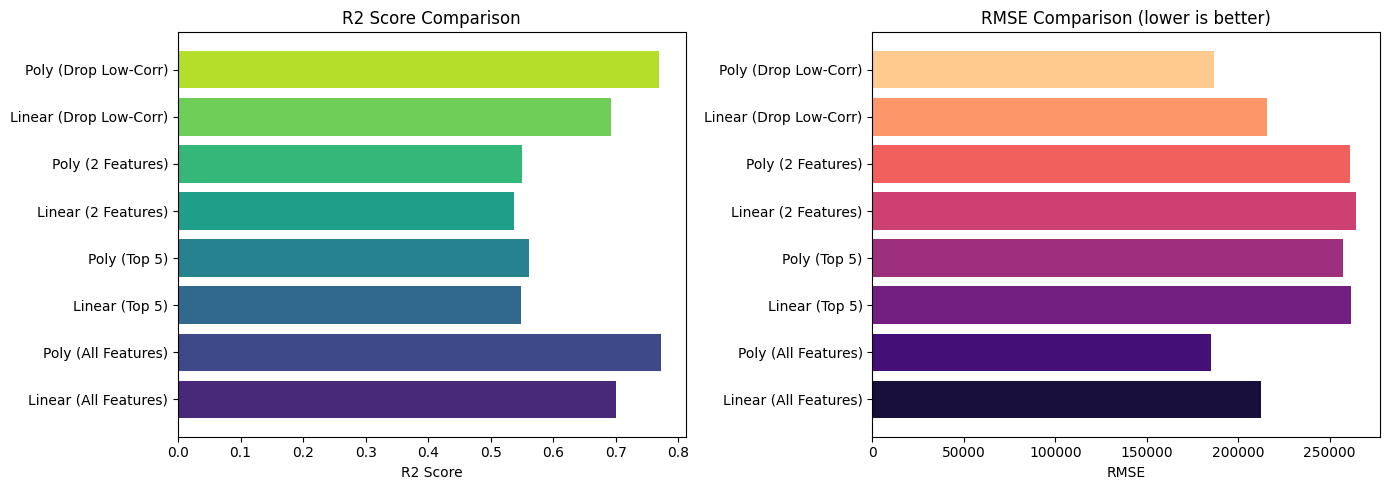

In [17]:
# ============================================
# VISUAL COMPARISON: R2 Scores
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score comparison
axes[0].barh(results["Model"], results["R2 Score"], color=sns.color_palette("viridis", len(results)))
axes[0].set_xlabel("R2 Score")
axes[0].set_title("R2 Score Comparison")
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# RMSE comparison
axes[1].barh(results["Model"], results["RMSE"], color=sns.color_palette("magma", len(results)))
axes[1].set_xlabel("RMSE")
axes[1].set_title("RMSE Comparison (lower is better)")

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# Experiment: Polynomial Degree Comparison
# ============================================
from sklearn.impute import SimpleImputer

# --- Setup: Top 5 features ---
top_features = ["sqft_living", "grade", "sqft_above", "sqft_living15", "bathrooms"]
X_top = df[top_features]
y_top = df["price"]

X_top_train, X_top_test, y_top_train, y_top_test = train_test_split(
    X_top, y_top, test_size=0.2, random_state=42
)
imp = SimpleImputer(strategy='median')
X_top_train = pd.DataFrame(imp.fit_transform(X_top_train), columns=top_features, index=X_top_train.index)
X_top_test = pd.DataFrame(imp.transform(X_top_test), columns=top_features, index=X_top_test.index)

# --- Setup: 2 features ---
minimal_features = ["sqft_living", "grade"]
X_min = df[minimal_features]
y_min = df["price"]
X_min_train, X_min_test, y_min_train, y_min_test = train_test_split(
    X_min, y_min, test_size=0.2, random_state=42
)

# --- Test degrees 2 to 5 with Top 5 features ---
degrees = [2, 3, 4, 5]
degree_results = []

for d in degrees:
    poly = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    poly.fit(X_top_train, y_top_train)
    pred = poly.predict(X_top_test)
    
    mae = mean_absolute_error(y_top_test, pred)
    rmse = np.sqrt(mean_squared_error(y_top_test, pred))
    r2 = r2_score(y_top_test, pred)
    
    degree_results.append({"Degree": d, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2 Score": round(r2, 4)})
    print(f"--- Top 5 Features | Degree {d} ---  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}")

degree_df = pd.DataFrame(degree_results)

# --- Test degrees 2 to 6 with 2 features ---
degrees_ext = [2, 3, 4, 5, 6]
deg_min_results = []

for d in degrees_ext:
    poly = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])
    poly.fit(X_min_train, y_min_train)
    pred = poly.predict(X_min_test)
    
    mae = mean_absolute_error(y_min_test, pred)
    rmse = np.sqrt(mean_squared_error(y_min_test, pred))
    r2 = r2_score(y_min_test, pred)
    
    deg_min_results.append({"Degree": d, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2 Score": round(r2, 4)})
    print(f"--- 2 Features     | Degree {d} ---  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}")

deg_min_df = pd.DataFrame(deg_min_results)

print("\n=== Top 5 Features ===")
print(degree_df.to_string(index=False))
print("\n=== 2 Features (sqft_living + grade) ===")
print(deg_min_df.to_string(index=False))

--- Top 5 Features | Degree 2 ---  MAE: 153448.05  RMSE: 257459.46  R2: 0.5615
--- Top 5 Features | Degree 3 ---  MAE: 153381.13  RMSE: 282570.90  R2: 0.4718


--- Top 5 Features | Degree 4 ---  MAE: 156614.65  RMSE: 340682.50  R2: 0.2323


--- Top 5 Features | Degree 5 ---  MAE: 156725.69  RMSE: 299145.75  R2: 0.4081
--- 2 Features     | Degree 2 ---  MAE: 158526.16  RMSE: 260992.82  R2: 0.5494
--- 2 Features     | Degree 3 ---  MAE: 158887.91  RMSE: 281465.22  R2: 0.4760
--- 2 Features     | Degree 4 ---  MAE: 159618.08  RMSE: 296596.88  R2: 0.4181
--- 2 Features     | Degree 5 ---  MAE: 158760.00  RMSE: 246357.67  R2: 0.5985
--- 2 Features     | Degree 6 ---  MAE: 171397.32  RMSE: 681572.07  R2: -2.0728

=== Top 5 Features ===
 Degree       MAE      RMSE  R2 Score
      2 153448.05 257459.46    0.5615
      3 153381.13 282570.90    0.4718
      4 156614.65 340682.50    0.2323
      5 156725.69 299145.75    0.4081

=== 2 Features (sqft_living + grade) ===
 Degree       MAE      RMSE  R2 Score
      2 158526.16 260992.82    0.5494
      3 158887.91 281465.22    0.4760
      4 159618.08 296596.88    0.4181
      5 158760.00 246357.67    0.5985
      6 171397.32 681572.07   -2.0728


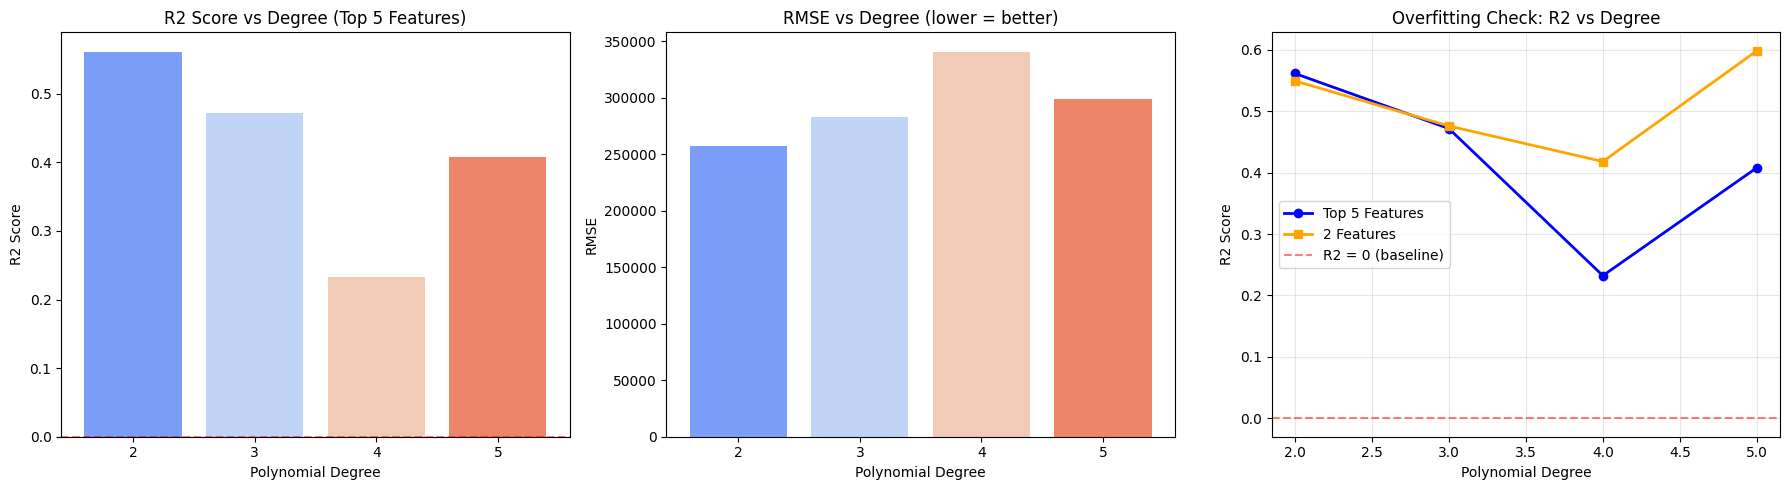


💡 KEY INSIGHT:
If R2 drops or goes negative at higher degrees → model is OVERFITTING!
The best degree is where R2 is highest on test data.


In [19]:
# ============================================
# Visual: Degree Comparison + Overfitting Analysis
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = sns.color_palette("coolwarm", len(degree_df))

# R2 Score bars by Degree (Top 5)
axes[0].bar(degree_df["Degree"].astype(str), degree_df["R2 Score"], color=colors)
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("R2 Score")
axes[0].set_title("R2 Score vs Degree (Top 5 Features)")
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# RMSE bars by Degree (Top 5)
axes[1].bar(degree_df["Degree"].astype(str), degree_df["RMSE"], color=colors)
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE vs Degree (lower = better)")

# Overfitting line plot
axes[2].plot(degree_df["Degree"], degree_df["R2 Score"], marker='o', linewidth=2, label="Top 5 Features", color='blue')
axes[2].plot(deg_min_df["Degree"][:len(degree_df)], deg_min_df["R2 Score"][:len(degree_df)], marker='s', linewidth=2, label="2 Features", color='orange')
axes[2].set_xlabel("Polynomial Degree")
axes[2].set_ylabel("R2 Score")
axes[2].set_title("Overfitting Check: R2 vs Degree")
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='R2 = 0 (baseline)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT:")
print("If R2 drops or goes negative at higher degrees → model is OVERFITTING!")
print("The best degree is where R2 is highest on test data.")